# Image Classification with ResNet50 in PyTorch

This notebook builds an end-to-end image classification pipeline for the `full_dataset` folder, where the labels are automatically inferred from the subfolder names such as `ripe`, `unripe`, and `overripe`.

## What this notebook covers
- Mount Google Drive in Google Colab
- Discover the dataset and create stratified train, validation, and test splits
- Apply preprocessing and data augmentation for transfer learning
- Fine-tune a pretrained ResNet50 model with partial layer freezing
- Train with EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint
- Save the best model and training history to Google Drive
- Evaluate the final model with plots, a confusion matrix, and a classification report

## Why this workflow is used
Transfer learning with ResNet50 is a strong baseline for image tasks because it starts from ImageNet features instead of learning everything from scratch. The validation split helps us monitor generalization during training, and the test split provides an unbiased final evaluation.

## 1. Environment Setup

This section imports the libraries used throughout the notebook and mounts Google Drive when the notebook is executed in Google Colab.

We do this first because the model checkpoint and the training history must be saved to Google Drive, and because all later sections depend on these libraries.

In [1]:
import torch
torch.cuda.is_available()

False

In [5]:
import json
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import cv2

from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from tqdm.auto import tqdm

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Google Colab was not detected. The notebook can still run locally if the paths below are updated.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.1 - resmove_duplicated images with embedding pretrained model**

In [3]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 44.1 MB/s eta 0:00:00


In [6]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import faiss
import shutil


def remove_similar_images(
    input_dir,
    output_dir,
    threshold=0.95,
    k=10,
    device=None
):
    """
    Remove duplicate/similar images using ResNet50 + FAISS

    Args:
        input_dir (str): folder of images
        output_dir (str): folder to move duplicates
        threshold (float): similarity threshold (0.9 - 0.99)
        k (int): number of neighbors to search
        device (str): 'cuda' or 'cpu'
    """

    # =========================
    # Device
    # =========================
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    os.makedirs(output_dir, exist_ok=True)

    # =========================
    # Model
    # =========================
    model = models.resnet50(pretrained=True)
    model = torch.nn.Sequential(*list(model.children())[:-1])
    model = model.to(device)
    model.eval()

    # =========================
    # Transform
    # =========================
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # =========================
    # Feature extractor
    # =========================
    def extract(img_path):
        img = cv2.imread(img_path)
        if img is None:
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = model(tensor)

        return feat.squeeze().cpu().numpy()

    # =========================
    # Load images
    # =========================
    paths = [
        os.path.join(input_dir, f)
        for f in os.listdir(input_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Found {len(paths)} images")

    # =========================
    # Extract features
    # =========================
    features = []
    valid_paths = []

    for p in paths:
        f = extract(p)
        if f is not None:
            features.append(f)
            valid_paths.append(p)

    features = np.array(features).astype("float32")

    # normalize
    faiss.normalize_L2(features)

    # =========================
    # FAISS index
    # =========================
    dim = features.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(features)

    # =========================
    # Search duplicates
    # =========================
    duplicates = set()

    for i in range(len(features)):
        if i in duplicates:
            continue

        D, I = index.search(np.expand_dims(features[i], axis=0), k)

        for score, idx in zip(D[0], I[0]):
            if idx == i:
                continue

            if score > threshold:
                duplicates.add(idx)

    # =========================
    # Move duplicates
    # =========================
    for idx in duplicates:
        src = valid_paths[idx]
        dst = os.path.join(output_dir, os.path.basename(src))
        shutil.move(src, dst)

    print(f"Done ✔ Moved {len(duplicates)} similar images")

    return len(duplicates)

clean dataset and drop images for the same embedding

In [ ]:

len_dup_overripe = remove_similar_images(
    "/content/drive/MyDrive/YaneCode-Digital-Stage/final_dataset/Overripe",
    "/content/drive/MyDrive/YaneCode-Digital-Stage/clean_dataset/Overripe",
    threshold=0.95,
    k=10,
    device=None
)
print("The lenght for duplicated images with treshold 0.95 : " + str(len_dup_overripe))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.3MB/s]


Found 22044 images


In [ ]:
len_dup_ripe = remove_similar_images(
    "/content/drive/MyDrive/YaneCode-Digital-Stage/final_dataset/Ripe",
    "/content/drive/MyDrive/YaneCode-Digital-Stage/clean_dataset/Ripe",
    threshold=0.95,
    k=10,
    device=None
)
print("The lenght for duplicated images with treshold 0.95 : " + str(len_dup_ripe))

In [ ]:
len_dup_unripe = remove_similar_images(
    "/content/drive/MyDrive/YaneCode-Digital-Stage/final_dataset/Unripe",
    "/content/drive/MyDrive/YaneCode-Digital-Stage/clean_dataset/Unripe",
    threshold=0.95,
    k=10,
    device=None
)
print("The lenght for duplicated images with treshold 0.95 : " + str(len_dup_unripe))

## 2. Reproducibility and Configuration

This section defines the training configuration, random seed, dataset path, and output paths.

It is important to centralize these settings so the experiment is reproducible, easy to modify, and ready to run in Google Colab without changing multiple cells.

In [ ]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_NAME = "resnet50_fruit_classifier"

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8, "The split ratios must add up to 1.0"

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DRIVE_ROOT = "/content/drive/MyDrive/YaneCode-Digital-Stage" if IN_COLAB else os.getcwd()
MANUAL_DATASET_DIR = "/content/drive/MyDrive/YaneCode-Digital-Stage/final_dataset"  # Example: "/content/drive/MyDrive/datasets/full_dataset"

dataset_candidates = [
    path for path in [
        MANUAL_DATASET_DIR
        # ,"/content/full_dataset",
        # os.path.join(DRIVE_ROOT, "full_dataset"),
        # os.path.join(os.getcwd(), "full_dataset"),
    ]
    if path is not None
]

DATASET_DIR = next((path for path in dataset_candidates if os.path.isdir(path)), None)
if DATASET_DIR is None:
    raise FileNotFoundError(
        "Could not find the 'full_dataset' folder. Put it in /content, MyDrive, or set MANUAL_DATASET_DIR."
    )

OUTPUT_DIR = os.path.join(DRIVE_ROOT, "image_classification_outputs_v2", MODEL_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")
HISTORY_JSON_PATH = os.path.join(OUTPUT_DIR, "training_history.json")
HISTORY_CSV_PATH = os.path.join(OUTPUT_DIR, "training_history.csv")

print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory : {OUTPUT_DIR}")


Using device: cuda
Dataset directory: /content/drive/MyDrive/YaneCode-Digital-Stage/final_dataset
Output directory : /content/drive/MyDrive/YaneCode-Digital-Stage/image_classification_outputs_v2/resnet50_fruit_classifier


## 3. Dataset Discovery and Stratified Splitting

This section reads the dataset from the `full_dataset` directory by using `ImageFolder`, which automatically converts subfolder names into class labels.

We then split the dataset into training, validation, and test sets with stratification so that each split preserves the class balance as much as possible.

In [ ]:
base_dataset = datasets.ImageFolder(DATASET_DIR)
class_names = base_dataset.classes
class_to_idx = base_dataset.class_to_idx
targets = np.array(base_dataset.targets)
all_indices = np.arange(len(base_dataset))

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=(1.0 - TRAIN_RATIO),
    stratify=targets,
    random_state=SEED,
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=targets[temp_indices],
    random_state=SEED,
)

split_sizes = {
    "train": len(train_indices),
    "validation": len(val_indices),
    "test": len(test_indices),
}

print(f"Classes discovered automatically from subfolders: {class_names}")
print(f"Class-to-index mapping: {class_to_idx}")
print(f"Split sizes: {split_sizes}")

class_mapping_df = pd.DataFrame(
    {"class_name": list(class_to_idx.keys()), "label_index": list(class_to_idx.values())}
)
display(class_mapping_df)

def build_split_summary(indices, split_name):
    counts = pd.Series(targets[indices]).value_counts().sort_index()
    total = len(indices)
    return pd.DataFrame(
        {
            "split": split_name,
            "class_name": class_names,
            "count": [counts.get(class_idx, 0) for class_idx in range(len(class_names))],
            "percentage": [counts.get(class_idx, 0) / total for class_idx in range(len(class_names))],
        }
    )

split_summary = pd.concat(
    [
        build_split_summary(train_indices, "train"),
        build_split_summary(val_indices, "validation"),
        build_split_summary(test_indices, "test"),
    ],
    ignore_index=True,
)

display(split_summary)


Classes discovered automatically from subfolders: ['Overripe', 'Ripe', 'Unripe']
Class-to-index mapping: {'Overripe': 0, 'Ripe': 1, 'Unripe': 2}
Split sizes: {'train': 35276, 'validation': 7559, 'test': 7560}


,class_name,label_index
0,Overripe,0
1,Ripe,1
2,Unripe,2


,split,class_name,count,percentage
0,train,Overripe,15431,0.437436
1,train,Ripe,10702,0.303379
2,train,Unripe,9143,0.259185
3,validation,Overripe,3306,0.437359
4,validation,Ripe,2293,0.303347
5,validation,Unripe,1960,0.259294
6,test,Overripe,3307,0.437434
7,test,Ripe,2294,0.303439
8,test,Unripe,1959,0.259127


## 4. Preprocessing and Data Augmentation

This section defines the image transformations and creates the `DataLoader` objects for each split.

The training set uses augmentation to improve generalization, while the validation and test sets only use deterministic preprocessing so that evaluation stays stable and fair.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = Subset(datasets.ImageFolder(DATASET_DIR, transform=train_transform), train_indices)
val_dataset = Subset(datasets.ImageFolder(DATASET_DIR, transform=eval_transform), val_indices)
test_dataset = Subset(datasets.ImageFolder(DATASET_DIR, transform=eval_transform), test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

Training batches   : 1103
Validation batches : 237
Test batches       : 237


## 5. Visual Check of Augmented Training Samples

This section displays a few images from the training loader after augmentation and normalization reversal.

It is a useful sanity check because it confirms that the preprocessing pipeline is working correctly before training begins.

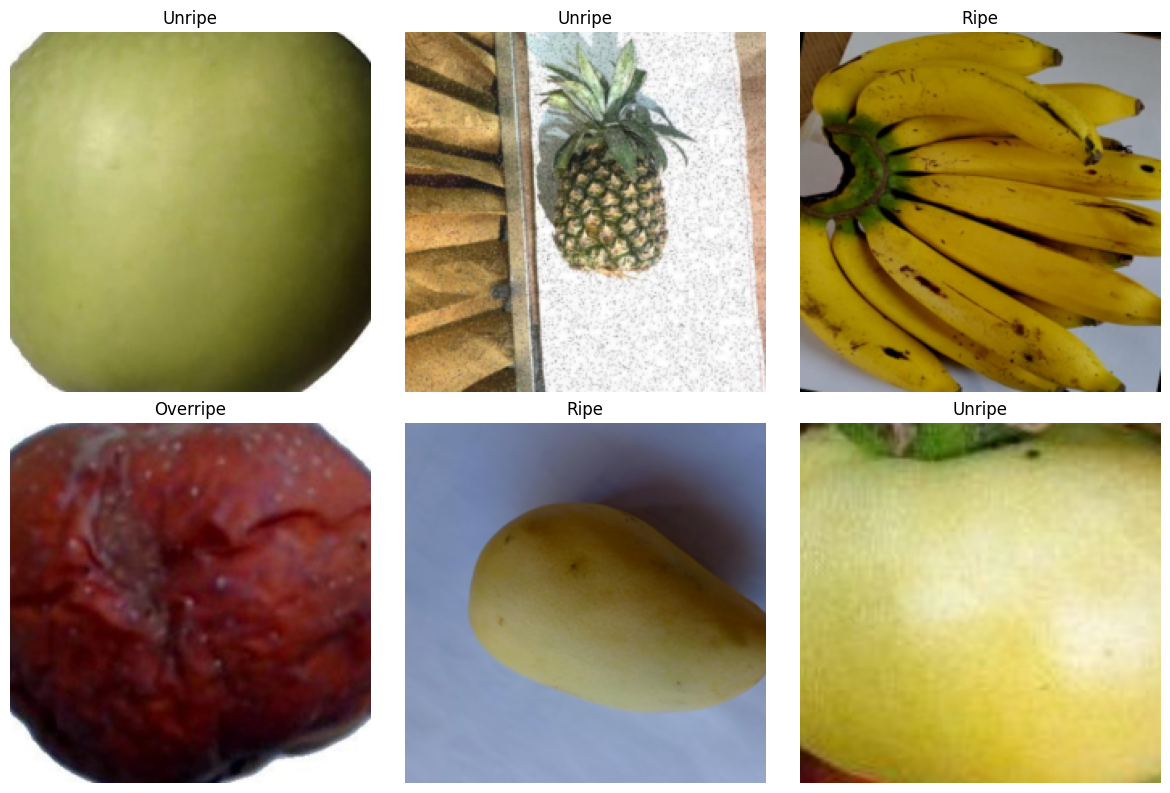

In [ ]:
def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu().clone()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean
    image = image.permute(1, 2, 0).clamp(0, 1).numpy()
    return image

preview_images, preview_labels = next(iter(val_loader))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for axis, image, label in zip(axes, preview_images[:6], preview_labels[:6]):
    axis.imshow(denormalize_image(image))
    axis.set_title(class_names[label.item()])
    axis.axis("off")

plt.tight_layout()
plt.show()


## 6. Model Definition and Partial Fine-Tuning

This section loads a ResNet50 model pretrained on ImageNet and adapts its classifier head to the number of classes discovered in the dataset.

To perform partial fine-tuning, the lower and middle feature extractor layers are frozen, while only the top feature block and the final classification head are trained. In this notebook:

- Frozen layers: `conv1`, `bn1`, `layer1`, `layer2`, `layer3`
- Unfrozen layers: `layer4`, `fc`

This strategy keeps most pretrained visual features intact while still allowing the network to adapt its high-level representations to the ripeness classification task.

In [ ]:
weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, len(class_names)),
)

for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

FROZEN_LAYERS = ["conv1", "bn1", "layer1", "layer2", "layer3"]
UNFROZEN_LAYERS = ["layer4", "fc"]

def count_parameters(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
model = model.to(device)

print("Frozen layers   :", FROZEN_LAYERS)
print("Trainable layers:", UNFROZEN_LAYERS)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


Frozen layers   : ['conv1', 'bn1', 'layer1', 'layer2', 'layer3']
Trainable layers: ['layer4', 'fc']
Total parameters    : 23,514,179
Trainable parameters: 14,970,883


## 7. Training Utilities

This section defines the loss function, optimizer, learning-rate scheduler, and callback-style helpers for EarlyStopping and ModelCheckpoint.

These utilities are important because they make training more stable, reduce overfitting risk, and ensure that the best-performing model is saved automatically to Google Drive.

In [ ]:
# criterion = nn.CrossEntropyLoss()

# optimizer = optim.AdamW(
#     (parameter for parameter in model.parameters() if parameter.requires_grad),
#     lr=LEARNING_RATE,
#     weight_decay=WEIGHT_DECAY,
# )

# scheduler = ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.5,
#     patience=2
# )

# class EarlyStopping:
#     def __init__(self, patience=5, min_delta=0.0):
#         self.patience = patience
#         self.min_delta = min_delta
#         self.best_value = np.inf
#         self.counter = 0

#     def step(self, current_value):
#         if current_value < self.best_value - self.min_delta:
#             self.best_value = current_value
#             self.counter = 0
#             return False

#         self.counter += 1
#         return self.counter >= self.patience


# class ModelCheckpoint:
#     def __init__(self, filepath, mode="min"):
#         self.filepath = filepath
#         self.mode = mode
#         self.best_value = np.inf if mode == "min" else -np.inf

#     def _is_improvement(self, current_value):
#         if self.mode == "min":
#             return current_value < self.best_value
#         return current_value > self.best_value

#     def step(self, current_value, model, optimizer, scheduler, epoch, history, class_names, class_to_idx):
#         if not self._is_improvement(current_value):
#             return False

#         self.best_value = current_value
#         checkpoint = {
#             "epoch": epoch,
#             "model_state_dict": model.state_dict(),
#             "optimizer_state_dict": optimizer.state_dict(),
#             "scheduler_state_dict": scheduler.state_dict(),
#             "best_monitored_value": current_value,
#             "class_names": class_names,
#             "class_to_idx": class_to_idx,
#             "frozen_layers": FROZEN_LAYERS,
#             "unfrozen_layers": UNFROZEN_LAYERS,
#             "history": history,
#         }
#         torch.save(checkpoint, self.filepath)
#         return True


# def set_frozen_backbone_eval(model):
#     for layer_name in FROZEN_LAYERS:
#         getattr(model, layer_name).eval()


# def run_one_epoch(model, loader, criterion, optimizer=None):
#     is_training = optimizer is not None

#     if is_training:
#         model.train()
#         set_frozen_backbone_eval(model)
#     else:
#         model.eval()

#     running_loss = 0.0
#     running_correct = 0
#     total_samples = 0

#     progress_bar = tqdm(loader, leave=False)
#     context_manager = torch.enable_grad() if is_training else torch.no_grad()

#     with context_manager:
#         for images, labels in progress_bar:
#             images = images.to(device, non_blocking=True)
#             labels = labels.to(device, non_blocking=True)

#             if is_training:
#                 optimizer.zero_grad(set_to_none=True)

#             outputs = model(images)
#             loss = criterion(outputs, labels)

#             if is_training:
#                 loss.backward()
#                 optimizer.step()

#             predictions = outputs.argmax(dim=1)
#             batch_size = images.size(0)

#             running_loss += loss.item() * batch_size
#             running_correct += (predictions == labels).sum().item()
#             total_samples += batch_size

#             progress_bar.set_description(
#                 f"{'Train' if is_training else 'Valid'} "
#                 f"Loss: {running_loss / total_samples:.4f} "
#                 f"Acc: {running_correct / total_samples:.4f}"
#             )

#     epoch_loss = running_loss / total_samples
#     epoch_accuracy = running_correct / total_samples
#     return epoch_loss, epoch_accuracy


# early_stopper = EarlyStopping(
#     patience=EARLY_STOPPING_PATIENCE,
#     min_delta=EARLY_STOPPING_MIN_DELTA,
# )

# model_checkpoint = ModelCheckpoint(BEST_MODEL_PATH, mode="min")




criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# ===================== EarlyStopping =====================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_value = np.inf
        self.counter = 0

    def step(self, current_value):
        if current_value < self.best_value - self.min_delta:
            self.best_value = current_value
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


# ===================== ModelCheckpoint =====================
class ModelCheckpoint:
    def __init__(self, filepath, mode="min"):
        self.filepath = filepath
        self.mode = mode
        self.best_value = np.inf if mode == "min" else -np.inf

    def _is_improvement(self, current_value):
        if self.mode == "min":
            return current_value < self.best_value
        return current_value > self.best_value

    def step(self, current_value, model, optimizer, scheduler, epoch, history, class_names, class_to_idx):
        if not self._is_improvement(current_value):
            return False

        self.best_value = current_value
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_monitored_value": current_value,
            "class_names": class_names,
            "class_to_idx": class_to_idx,
            "frozen_layers": FROZEN_LAYERS,
            "unfrozen_layers": UNFROZEN_LAYERS,
            "history": history,
        }
        torch.save(checkpoint, self.filepath)
        return True


def set_frozen_backbone_eval(model):
    for layer_name in FROZEN_LAYERS:
        getattr(model, layer_name).eval()


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
        set_frozen_backbone_eval(model)
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    progress_bar = tqdm(loader, leave=False)
    context_manager = torch.enable_grad() if is_training else torch.no_grad()

    with context_manager:
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            bs = images.size(0)

            running_loss += loss.item() * bs
            running_correct += (preds == labels).sum().item()
            total_samples += bs

            progress_bar.set_description(
                f"{'Train' if is_training else 'Valid'} "
                f"Loss: {running_loss / total_samples:.4f} "
                f"Acc: {running_correct / total_samples:.4f}"
            )

    return running_loss / total_samples, running_correct / total_samples


early_stopper = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
)

model_checkpoint = ModelCheckpoint(BEST_MODEL_PATH, mode="min")

# ===================== 🔥 RESUME TRAINING =====================
start_epoch = 1

try:
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]

    early_stopper.best_value = checkpoint["best_monitored_value"]
    model_checkpoint.best_value = checkpoint["best_monitored_value"]

    print(f"✅ Resuming from epoch {start_epoch}")

except FileNotFoundError:
    print("⚠️ No checkpoint found, starting from scratch")

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "learning_rate": [],
    }

✅ Resuming from epoch 8


## 8. Training Loop with EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint

This section trains the model, tracks loss and accuracy on the training and validation sets, reduces the learning rate when the validation loss plateaus, and stops training early if improvement stalls.

The training history is saved after every epoch so progress is not lost, and the best model checkpoint is written to Google Drive whenever the validation loss improves.

In [ ]:
# history = {
#     "epoch": [],
#     "train_loss": [],
#     "val_loss": [],
#     "train_accuracy": [],
#     "val_accuracy": [],
#     "learning_rate": [],
# }

# best_epoch = None
# start_time = time.time()

# for epoch in range(start_epoch, EPOCHS + 1):
#     print(f"\nEpoch {epoch}/{EPOCHS}")

#     train_loss, train_accuracy = run_one_epoch(model, train_loader, criterion, optimizer)
#     val_loss, val_accuracy = run_one_epoch(model, val_loader, criterion)

#     current_learning_rate = optimizer.param_groups[0]["lr"]

#     history["epoch"].append(epoch)
#     history["train_loss"].append(float(train_loss))
#     history["val_loss"].append(float(val_loss))
#     history["train_accuracy"].append(float(train_accuracy))
#     history["val_accuracy"].append(float(val_accuracy))
#     history["learning_rate"].append(float(current_learning_rate))

#     scheduler.step(val_loss)

#     checkpoint_saved = model_checkpoint.step(
#         current_value=val_loss,
#         model=model,
#         optimizer=optimizer,
#         scheduler=scheduler,
#         epoch=epoch,
#         history=history,
#         class_names=class_names,
#         class_to_idx=class_to_idx,
#     )

#     pd.DataFrame(history).to_csv(HISTORY_CSV_PATH, index=False)
#     with open(HISTORY_JSON_PATH, "w") as history_file:
#         json.dump(history, history_file, indent=2)

#     print(
#         f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
#         f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | "
#         f"LR: {current_learning_rate:.6f}"
#     )

#     if checkpoint_saved:
#         best_epoch = epoch
#         print(f"Validation loss improved. Best model saved to: {BEST_MODEL_PATH}")

#     if early_stopper.step(val_loss):
#         print("Early stopping triggered because validation loss stopped improving.")
#         break

# elapsed_minutes = (time.time() - start_time) / 60
# history_df = pd.DataFrame(history)

# print(f"\nTraining finished in {elapsed_minutes:.2f} minutes.")
# print(f"Best model checkpoint: {BEST_MODEL_PATH}")
# print(f"History JSON file   : {HISTORY_JSON_PATH}")
# print(f"History CSV file    : {HISTORY_CSV_PATH}")
# print(f"Best epoch          : {best_epoch}")
# display(history_df.tail())



best_epoch = None
start_time = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion)

    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))
    history["train_accuracy"].append(float(train_acc))
    history["val_accuracy"].append(float(val_acc))
    history["learning_rate"].append(float(lr))

    scheduler.step(val_loss)

    checkpoint_saved = model_checkpoint.step(
        current_value=val_loss,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        history=history,
        class_names=class_names,
        class_to_idx=class_to_idx,
    )

    pd.DataFrame(history).to_csv(HISTORY_CSV_PATH, index=False)
    with open(HISTORY_JSON_PATH, "w") as f:
        json.dump(history, f, indent=2)

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {lr:.6f}"
    )

    if checkpoint_saved:
        best_epoch = epoch
        print(f"✅ Best model saved at epoch {epoch}")

    if early_stopper.step(val_loss):
        print("⛔ Early stopping triggered")
        break

elapsed = (time.time() - start_time) / 60

print(f"\n⏱ Training finished in {elapsed:.2f} min")
print(f"🏆 Best epoch: {best_epoch}")


Epoch 8/20


  0%|          | 0/1103 [00:00<?, ?it/s]

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss: 0.0688 | Train Acc: 0.9715 | Val Loss: 0.1315 | Val Acc: 0.9562 | LR: 0.000100

Epoch 9/20


  0%|          | 0/1103 [00:00<?, ?it/s]

...

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss: 0.0468 | Train Acc: 0.9801 | Val Loss: 0.1416 | Val Acc: 0.9552 | LR: 0.000050

Epoch 12/20


  0%|          | 0/1103 [00:00<?, ?it/s]

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss: 0.0406 | Train Acc: 0.9824 | Val Loss: 0.1408 | Val Acc: 0.9586 | LR: 0.000050
⛔ Early stopping triggered

⏱ Training finished in 215.64 min
🏆 Best epoch: None


## 9. Training Curves

This section visualizes the training and validation loss and accuracy recorded during training.

These plots help diagnose underfitting, overfitting, convergence behavior, and the general stability of the fine-tuning process.

In [ ]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Training Accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Final Evaluation on the Test Set

This section reloads the best checkpoint saved during training and evaluates it on the held-out test set.

This is done at the end so that the final metrics reflect the best model selected on validation performance rather than the last training epoch.

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

test_running_loss = 0.0
test_running_correct = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)

        batch_size = images.size(0)
        test_running_loss += loss.item() * batch_size
        test_running_correct += (predictions == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

test_loss = test_running_loss / len(test_dataset)
test_accuracy = test_running_correct / len(test_dataset)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

confusion_mat = confusion_matrix(all_labels, all_predictions)
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix on the Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))


## 11. Saved Outputs

This final section summarizes the main files saved to Google Drive.

Keeping the output paths visible makes it easier to reuse the trained checkpoint later for inference or additional fine-tuning.

In [ ]:
saved_artifacts = pd.DataFrame(
    {
        "artifact": [
            "Best model checkpoint",
            "Training history (JSON)",
            "Training history (CSV)",
        ],
        "path": [
            BEST_MODEL_PATH,
            HISTORY_JSON_PATH,
            HISTORY_CSV_PATH,
        ],
    }
)

display(saved_artifacts)
